In [ ]:
!pip install diffusers transformers accelerate imageio

In [ ]:
import torch
from diffusers import AnimateDiffPipeline, MotionAdapter, DDIMScheduler
from diffusers.utils import export_to_gif

# 1. Load the motion adapter (this teaches the static model how things move over time)
adapter = MotionAdapter.from_pretrained(
    "guoyww/animatediff-motion-adapter-v1-5-2",
    torch_dtype=torch.float16
)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomme

config.json:   0%|          | 0.00/455 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.82G [00:00<?, ?B/s]

The config attributes {'motion_activation_fn': 'geglu', 'motion_attention_bias': False, 'motion_cross_attention_dim': None} were passed to MotionAdapter, but are not expected and will be ignored. Please verify your config.json configuration file.


In [ ]:
# 2. Load the base Stable Diffusion model and combine it with the adapter
pipe = AnimateDiffPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    motion_adapter=adapter,
    torch_dtype=torch.float16
)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# 3. Set a specific scheduler optimized for video
pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config,
    clip_sample=False,
    timestep_spacing="linspace",
    steps_offset=1
)

In [ ]:
# 4. Memory Optimization (Crucial for avoiding crashes on standard GPUs)
pipe.enable_model_cpu_offload()
pipe.enable_vae_slicing()

print("Video pipeline successfully loaded!")

Video pipeline successfully loaded!


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2186: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `AnimateDiffPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


In [ ]:
prompt = "A cinematic low-angle drone shot of a futuristic smart farm at sunrise. Green crops in perfect rows. A small, sleek autonomous robot with blue glowing lights is slowly moving between the rows watering plants. Golden hour lighting, lens flare, 4k resolution, highly detailed, slow smooth motion."
negative_prompt = "bad quality, distorted, static, motionless, low resolution"

print("Generating frames... (This may take a few minutes depending on your hardware)")

output = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_frames=16,
    guidance_scale=7.5,
    num_inference_steps=25,
)

Generating frames... (This may take a few minutes depending on your hardware)


  0%|          | 0/25 [00:00<?, ?it/s]

Animation saved successfully as simple_animation.gif!


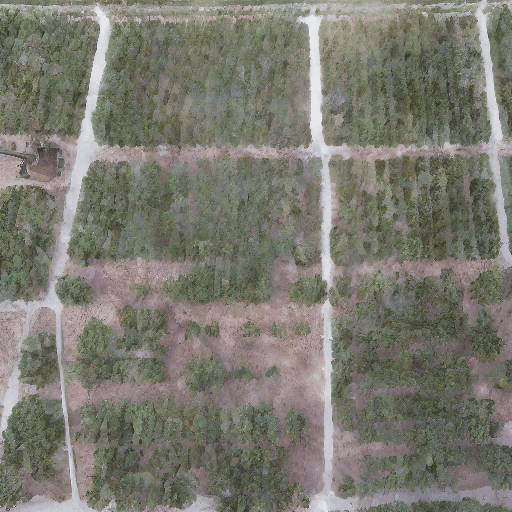

In [ ]:
# 3. Export the resulting frames to a viewable format
gif_path = "simple_animation.gif"
export_to_gif(output.frames[0], gif_path)

print(f"Animation saved successfully as {gif_path}!")

from IPython.display import Image
display(Image(open(gif_path, 'rb').read()))